In [24]:
from collections import Counter

In [2]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [4]:
from imblearn.datasets import fetch_datasets
from imblearn.pipeline import pipeline
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    SVMSMOTE
)

In [28]:
from imblearn.pipeline import Pipeline


In [5]:
oversampler_dict = {
    'random': RandomOverSampler(
    sampling_strategy='auto',
    random_state=0,
),
    'smote': SMOTE(sampling_strategy='auto', random_state=0, k_neighbors=5),
    'adasyn': ADASYN(sampling_strategy='auto', random_state=0, n_neighbors=5),
    'border1': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
),
    'border2': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-2',
),
    'svm': SVMSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=SVC(kernel='linear'),
    out_step=0.5,
)}

In [7]:
fetch_datasets().keys()

odict_keys(['ecoli', 'optical_digits', 'satimage', 'pen_digits', 'abalone', 'sick_euthyroid', 'spectrometer', 'car_eval_34', 'isolet', 'us_crime', 'yeast_ml8', 'scene', 'libras_move', 'thyroid_sick', 'coil_2000', 'arrhythmia', 'solar_flare_m0', 'oil', 'car_eval_4', 'wine_quality', 'letter_img', 'yeast_me2', 'webpage', 'ozone_level', 'mammography', 'protein_homo', 'abalone_19'])

In [16]:
for item in fetch_datasets().keys():
    print("'"+item+"'"+',')

'ecoli',
'optical_digits',
'satimage',
'pen_digits',
'abalone',
'sick_euthyroid',
'spectrometer',
'car_eval_34',
'isolet',
'us_crime',
'yeast_ml8',
'scene',
'libras_move',
'thyroid_sick',
'coil_2000',
'arrhythmia',
'solar_flare_m0',
'oil',
'car_eval_4',
'wine_quality',
'letter_img',
'yeast_me2',
'webpage',
'ozone_level',
'mammography',
'protein_homo',
'abalone_19',


In [ ]:
# datasets_ls = 
#     for item in fetch_datasets().keys():
#     print("'"+item+"'"+',')
# 

SyntaxError: invalid syntax (4165915858.py, line 2)

In [20]:
datasets_ls = [item for item in fetch_datasets().keys()]

In [21]:
datasets_ls

['ecoli',
 'optical_digits',
 'satimage',
 'pen_digits',
 'abalone',
 'sick_euthyroid',
 'spectrometer',
 'car_eval_34',
 'isolet',
 'us_crime',
 'yeast_ml8',
 'scene',
 'libras_move',
 'thyroid_sick',
 'coil_2000',
 'arrhythmia',
 'solar_flare_m0',
 'oil',
 'car_eval_4',
 'wine_quality',
 'letter_img',
 'yeast_me2',
 'webpage',
 'ozone_level',
 'mammography',
 'protein_homo',
 'abalone_19']

In [22]:
len(datasets_ls)

27

In [25]:
for dataset in datasets_ls:
    data = fetch_datasets()[dataset]
    print(dataset)
    print(Counter(data.target))
    print()

ecoli
Counter({np.int64(-1): 301, np.int64(1): 35})

optical_digits
Counter({np.int64(-1): 5066, np.int64(1): 554})

satimage
Counter({np.int64(-1): 5809, np.int64(1): 626})

pen_digits
Counter({np.int64(-1): 9937, np.int64(1): 1055})

abalone
Counter({np.int64(-1): 3786, np.int64(1): 391})

sick_euthyroid
Counter({np.int64(-1): 2870, np.int64(1): 293})

spectrometer
Counter({np.int64(-1): 486, np.int64(1): 45})

car_eval_34
Counter({np.int64(-1): 1594, np.int64(1): 134})

isolet
Counter({np.int64(-1): 7197, np.int64(1): 600})

us_crime
Counter({np.int64(-1): 1844, np.int64(1): 150})

yeast_ml8
Counter({np.int64(-1): 2239, np.int64(1): 178})

scene
Counter({np.int64(-1): 2230, np.int64(1): 177})

libras_move
Counter({np.int64(-1): 336, np.int64(1): 24})

thyroid_sick
Counter({np.int64(-1): 3541, np.int64(1): 231})

coil_2000
Counter({np.int64(-1): 9236, np.int64(1): 586})

arrhythmia
Counter({np.int64(-1): 427, np.int64(1): 25})

solar_flare_m0
Counter({np.int64(-1): 1321, np.int64(1):

In [40]:
def run_model(X_train, y_train, oversampler=None):

    #set up the classifier
    rf = RandomForestClassifier(
        n_estimators=100, random_state=0, max_depth=3
    )

    scaler = MinMaxScaler()

    if not oversampler:

        model = rf

        rf_params = {
            'n_estimators': [10, 50, 100, 500],
            'max_depth': [1,2,3,4]
        }
    
    #set up a pipeline with sampling
    else:
        model = Pipeline([
            ('scaler', scaler),
            ('sampler', oversampler),
            ('model', rf)
        ])

        rf_params = {
            'model__n_estimators': [10,50,100,500],
            'model__max_depth': [1,2,3,4]
        }

    search = RandomizedSearchCV(
            model,
            rf_params,
            random_state=0,
            scoring='roc_auc'
        )

    search.fit(X_train, y_train)

    print('Best parameters: {0}, \n Best score: {1}'.format(search.best_params_, search.best_score_))

    return search

In [41]:
test = run_model(X_train, y_train)
dir(test)

Best parameters: {'n_estimators': 100, 'max_depth': 4}, 
 Best score: 0.923670150987224


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_refit_for_multimetric',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_run_sea

In [42]:

mean_dict = {}
std_dict = {}

for dataset in datasets_ls:

    mean_dict[dataset] = {}
    std_dict[dataset] = {}

    print(dataset)

    data = fetch_datasets()[dataset]

    X_train, X_test, y_train, y_test = train_test_split(
        data.data,
        data.target,
        test_size=0.3,
        random_state=0
    )

    #training model on data without resampling
    #with cross-validation
    search = run_model(X_train, y_train)

    m, s = pd.DataFrame(search.cv_results_).sort_values(
        by='mean_test_score',
        ascending=False).loc[0, ['mean_test_score', 'std_test_score']].values
    
    #Storing results
    mean_dict[dataset]['full_data'] = m
    std_dict[dataset]['full_data'] = s

    print()

    for oversampler in oversampler_dict.keys():

        print(oversampler)

        search = run_model(X_train, y_train, oversampler_dict[oversampler])

        m, s = pd.DataFrame(search.cv_results_).sort_values(
            by="mean_test_score",
            ascending=False).loc[0, ['mean_test_score', 'std_test_score']].values
        
        #store results
        mean_dict[dataset][oversampler] = m
        std_dict[dataset][oversampler] = s
        print()
    
    print()

ecoli
Best parameters: {'n_estimators': 100, 'max_depth': 4}, 
 Best score: 0.923670150987224

random
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 2}, 
 Best score: 0.9096631823461092

smote
Best parameters: {'model__n_estimators': 10, 'model__max_depth': 3}, 
 Best score: 0.9246806039488966

adasyn
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 2}, 
 Best score: 0.9221835075493612

border1
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 2}, 
 Best score: 0.9106155632984901

border2
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 2}, 
 Best score: 0.9080603948896633

svm
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 4}, 
 Best score: 0.9127990708478514


optical_digits
Best parameters: {'n_estimators': 100, 'max_depth': 4}, 
 Best score: 0.98310883834685

random
Best parameters: {'model__n_estimators': 100, 'model__max_depth': 4}, 
 Best score: 0.9823077271585696

smote
Best parameters: {'mo

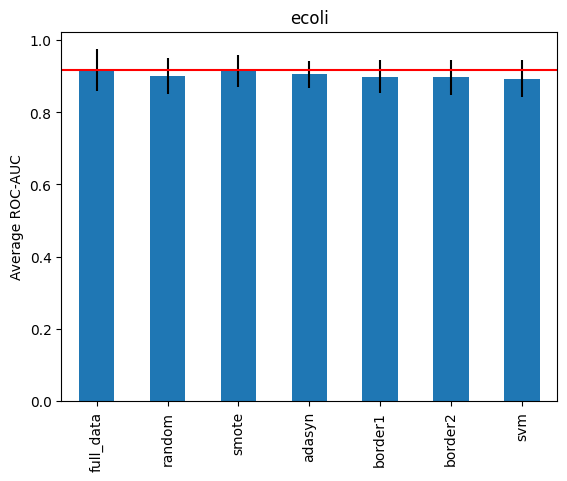

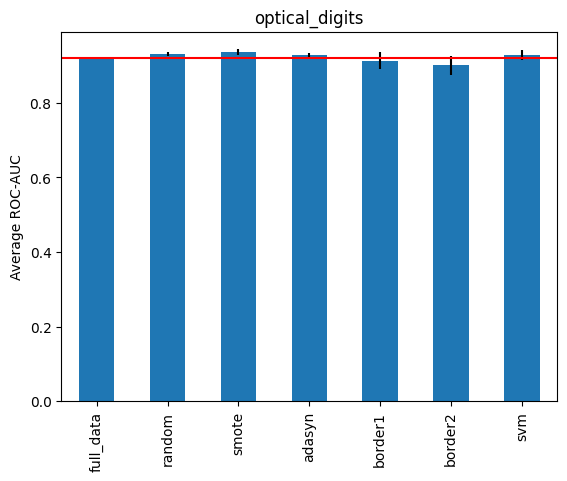

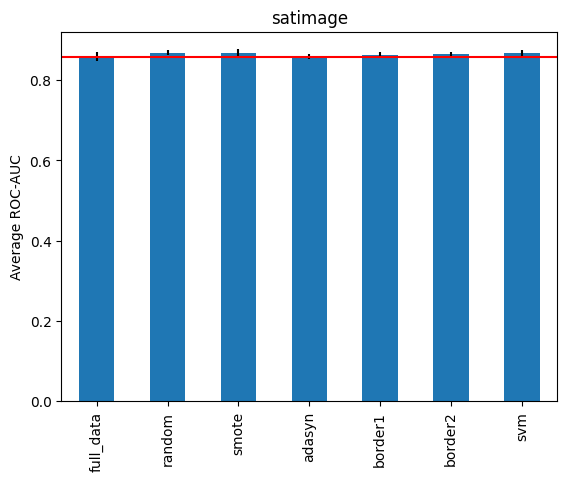

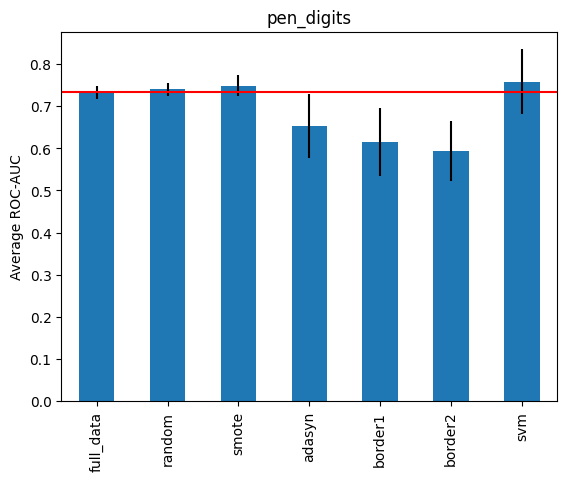

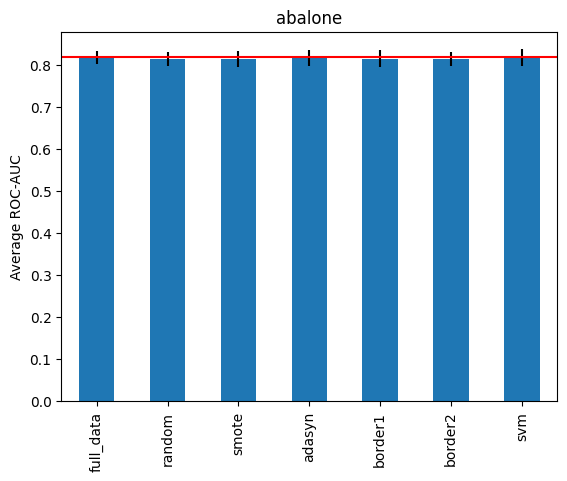

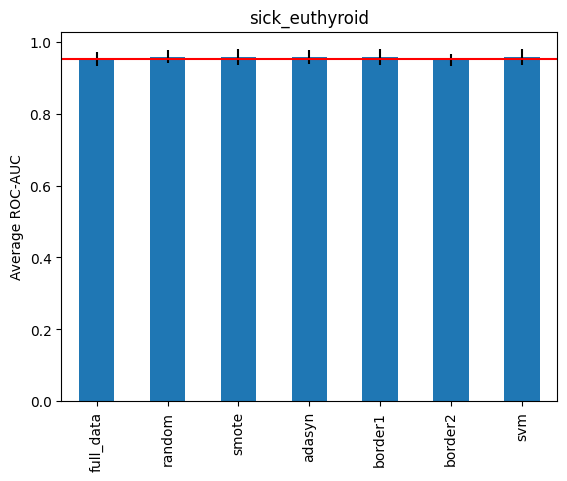

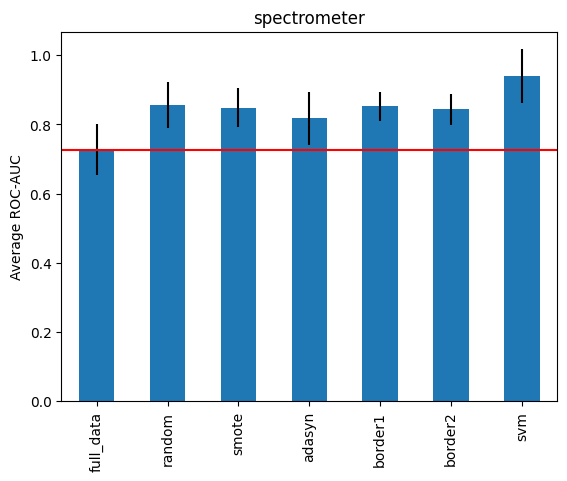

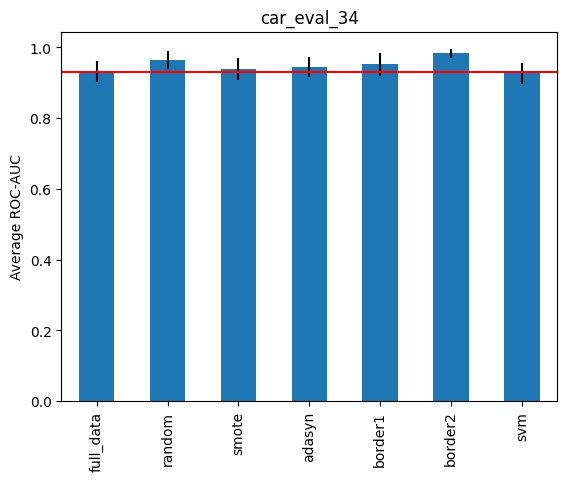

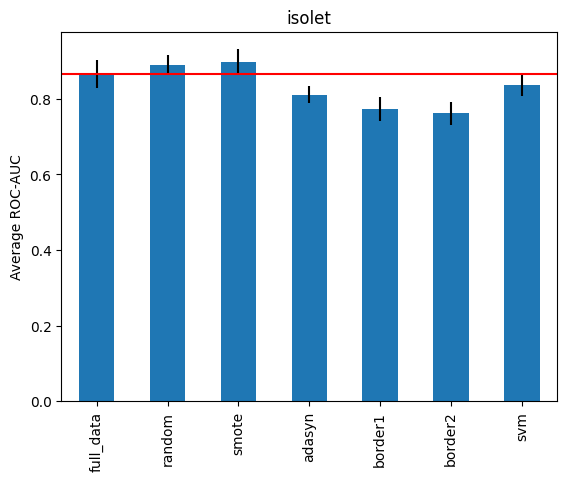

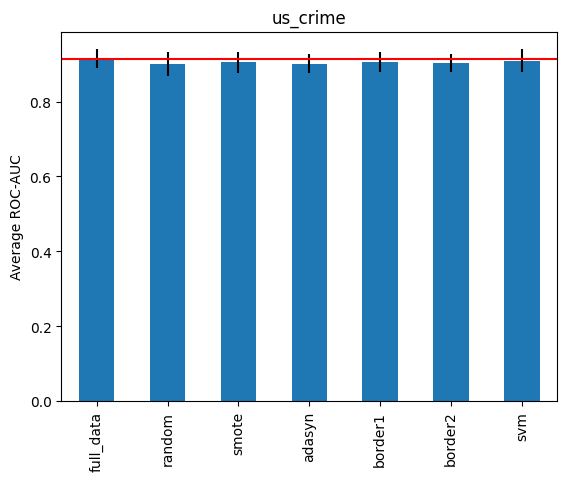

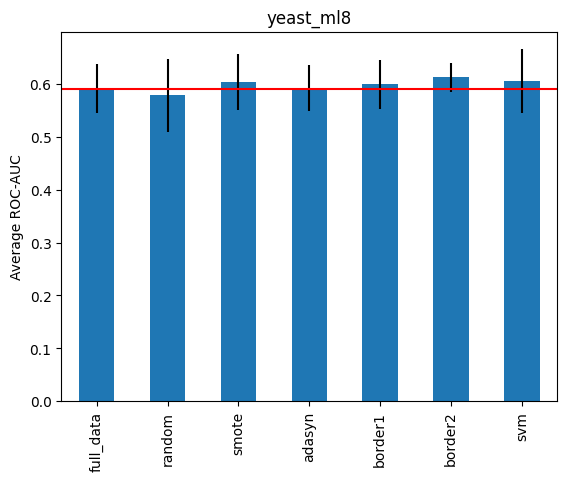

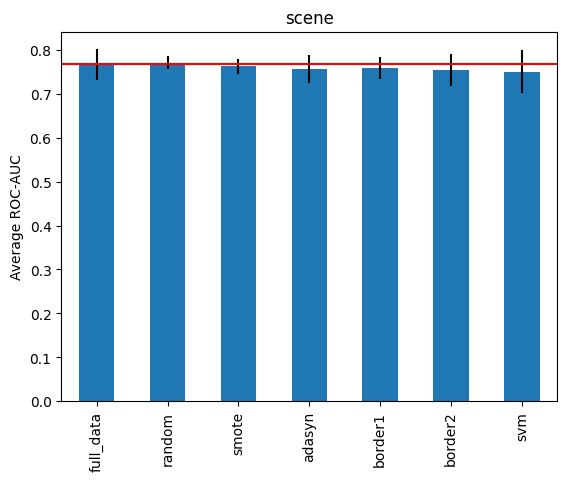

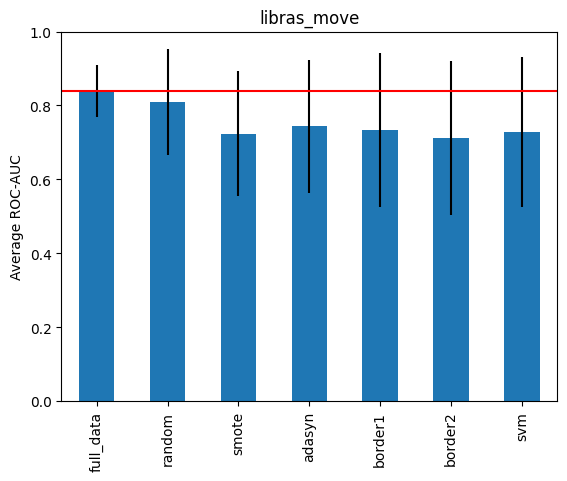

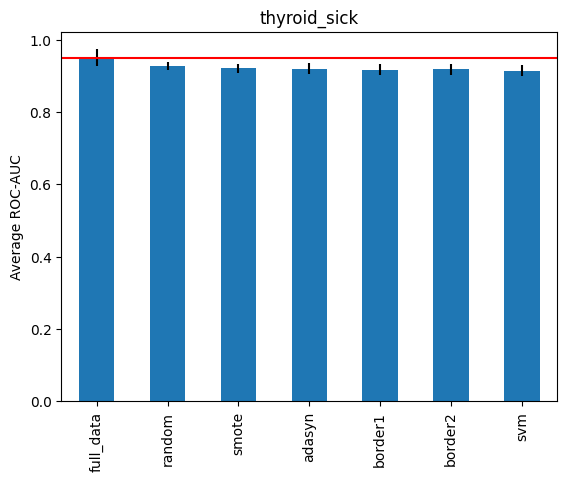

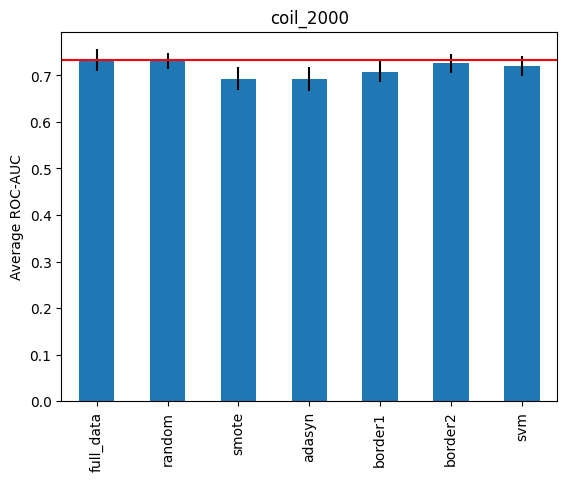

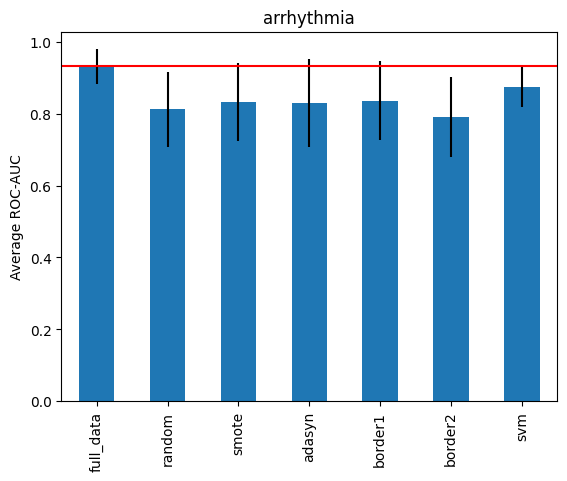

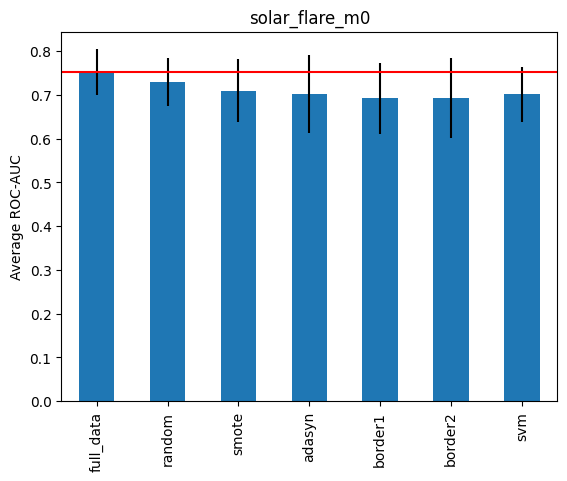

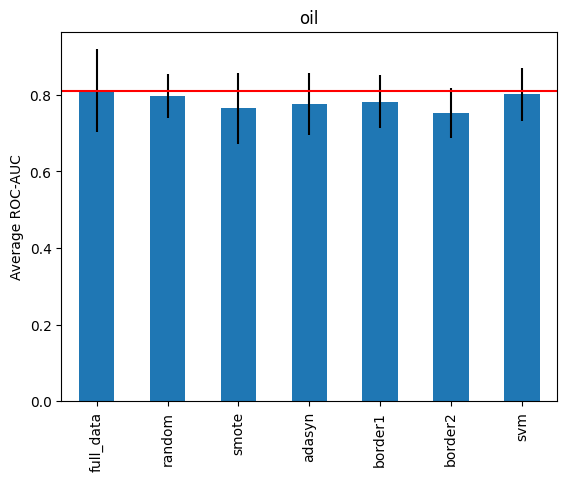

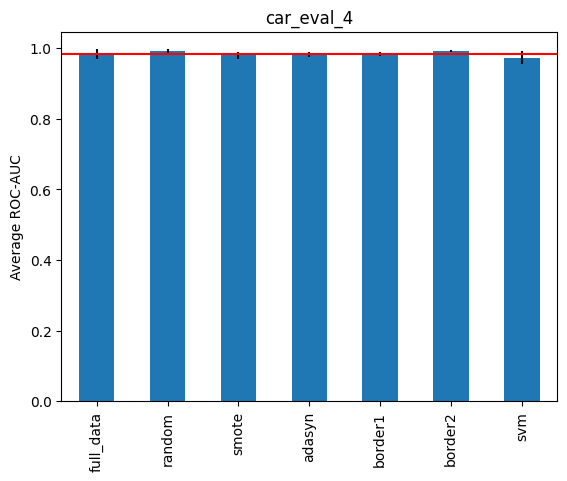

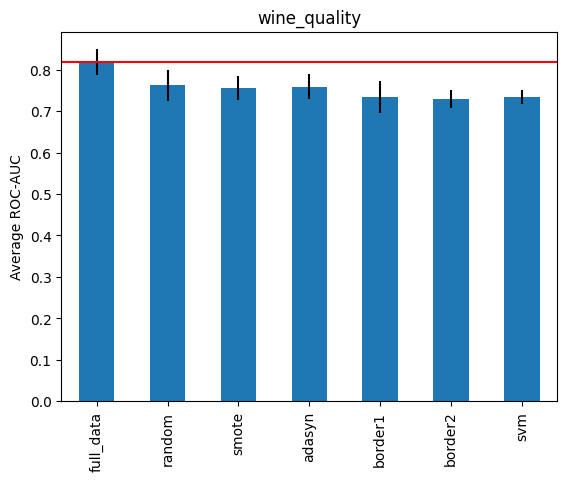

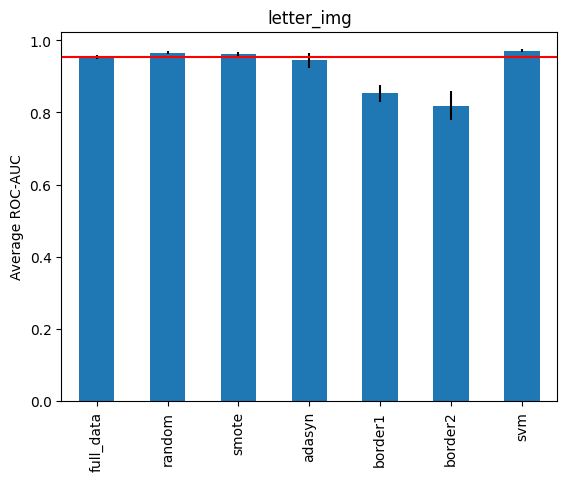

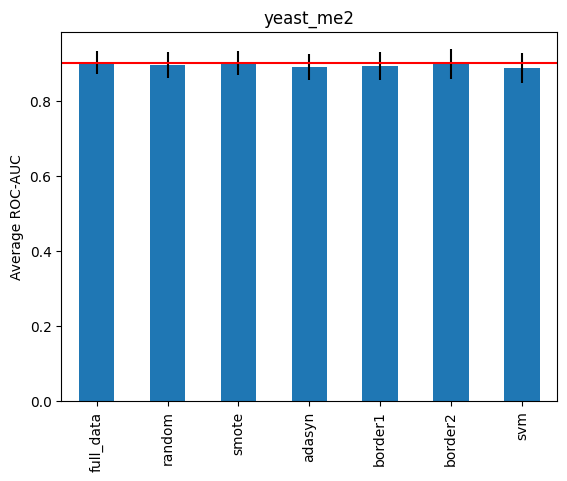

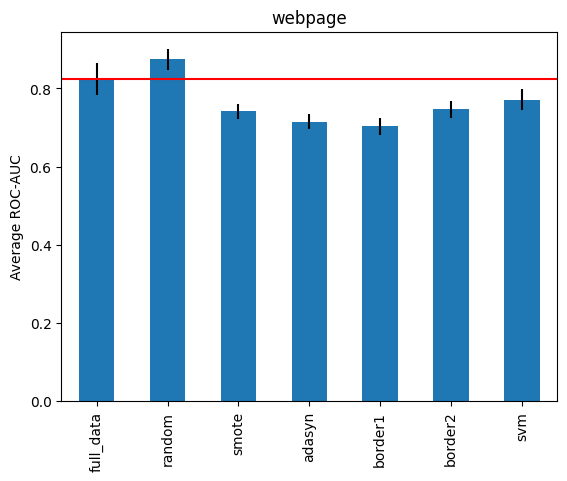

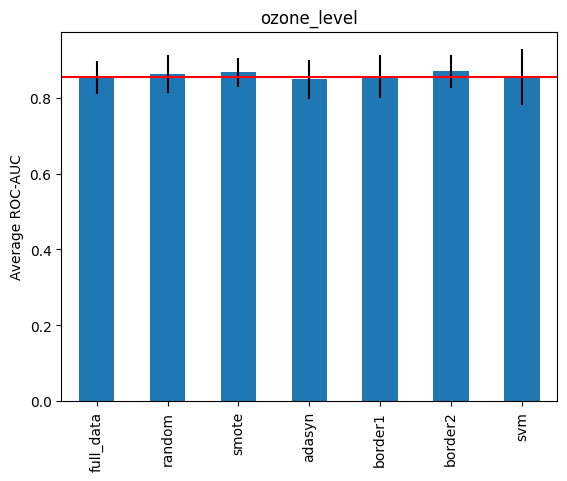

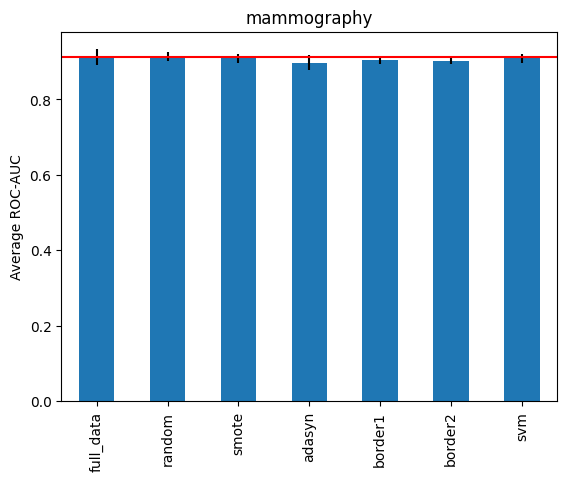

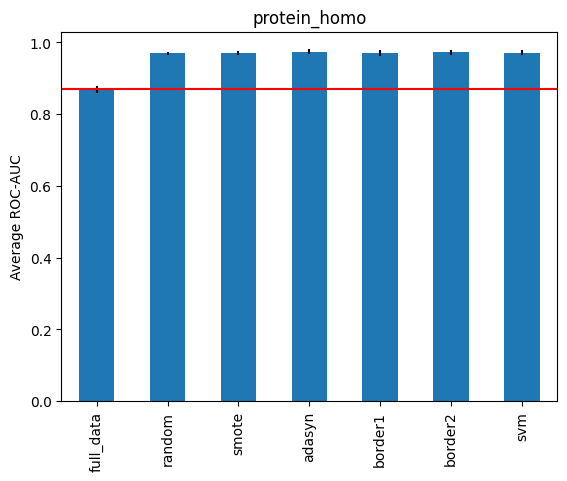

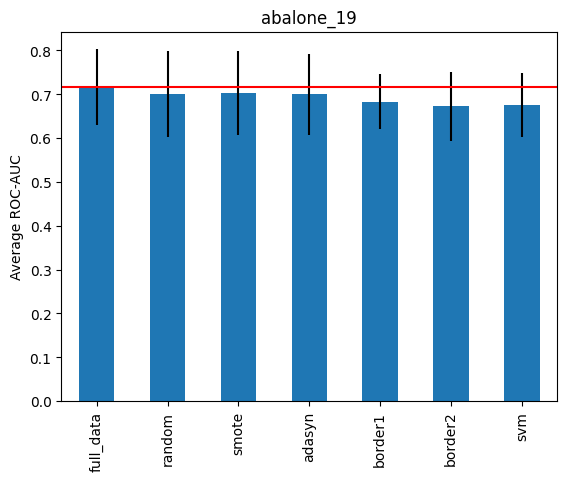

In [43]:
for dataset in datasets_ls:

    mean_series = pd.Series(mean_dict[dataset])
    std_series = pd.Series(std_dict[dataset])

    mean_series.plot.bar(yerr=std_series)

    plt.title(dataset)
    plt.ylabel('Average ROC-AUC')
    plt.axhline(mean_dict[dataset]['full_data'], color='r')
    plt.show()